# 03 — Baseline Comparison

**Goal:** Compare the trained spiking R-STDP agent against three conventional
RL baselines on the same environment.

Baselines:
- **Random policy** — uniform action sampling.
- **BFS-optimal** — shortest path using breadth-first search.
- **Tabular Q-learning** — classic tabular RL.
- **DQN** — deep Q-network with replay buffer (Mnih et al., 2015).
- **PPO** — proximal policy optimization (Schulman et al., 2017).

All baselines run on the same 5×5 gridworld with dense step rewards.

In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import json

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spiking_rl.environment.gridworld import GridWorldEnv
from spiking_rl.baselines.tabular_q import TabularQAgent, TabularQConfig
from spiking_rl.baselines.dqn import DQNAgent, DQNConfig
from spiking_rl.baselines.ppo import PPOAgent, PPOConfig

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Torch: {torch.__version__}")

Torch: 2.14.0+cpu


In [2]:
def make_env() -> GridWorldEnv:
    return GridWorldEnv(
        size=5,
        start=(0, 0),
        goal=(4, 4),
        max_steps=100,
        step_reward=-0.01,
        render_mode=None,
    )

# Sanity check
env = make_env()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box(0.0, 1.0, (4,), float32)
Action space: Discrete(4)


## Reference baselines (random, BFS-optimal)

These come from notebook 02 but are re-computed here so this notebook is
self-contained.

In [3]:
from collections import deque

_DIRECTION_TO_ACTION = {
    tuple(v): k for k, v in GridWorldEnv._ACTION_TO_DIRECTION.items()
}

def bfs_next_action(env):
    start = (int(env._agent_pos[0]), int(env._agent_pos[1]))
    goal = (int(env.goal[0]), int(env.goal[1]))
    if start == goal:
        return None
    size = env.size
    obstacles = env.obstacles
    queue = deque([start])
    came_from = {start: None}
    came_from_action = {start: None}
    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for action, delta in GridWorldEnv._ACTION_TO_DIRECTION.items():
            dr, dc = int(delta[0]), int(delta[1])
            nxt = (current[0] + dr, current[1] + dc)
            if not (0 <= nxt[0] < size and 0 <= nxt[1] < size):
                continue
            if nxt in obstacles or nxt in came_from:
                continue
            came_from[nxt] = current
            came_from_action[nxt] = action
            queue.append(nxt)
    if goal not in came_from:
        return None
    node = goal
    path_actions = []
    while came_from[node] is not None:
        path_actions.append(came_from_action[node])
        node = came_from[node]
    path_actions.reverse()
    return path_actions[0] if path_actions else None


def random_episode(env, seed):
    obs, _ = env.reset(seed=seed)
    r = 0.0
    s = 0
    term = trunc = False
    for _ in range(200):
        obs, r_i, term, trunc, _ = env.step(env.action_space.sample())
        r += r_i
        s += 1
        if term or trunc:
            break
    return {"total_reward": r, "steps": s, "success": bool(term and not trunc)}


def bfs_episode(env, seed):
    obs, _ = env.reset(seed=seed)
    r = 0.0
    s = 0
    term = trunc = False
    for _ in range(200):
        a = bfs_next_action(env)
        if a is None:
            a = 0
        obs, r_i, term, trunc, _ = env.step(a)
        r += r_i
        s += 1
        if term or trunc:
            break
    return {"total_reward": r, "steps": s, "success": bool(term and not trunc)}


N_EVAL_REF = 50
random_results = [random_episode(make_env(), seed=i) for i in range(N_EVAL_REF)]
bfs_results = [bfs_episode(make_env(), seed=1000 + i) for i in range(N_EVAL_REF)]

random_summary = {
    "mean_reward": float(np.mean([r["total_reward"] for r in random_results])),
    "success_rate": float(np.mean([r["success"] for r in random_results])),
    "mean_steps": float(np.mean([r["steps"] for r in random_results])),
}
bfs_summary = {
    "mean_reward": float(np.mean([r["total_reward"] for r in bfs_results])),
    "success_rate": float(np.mean([r["success"] for r in bfs_results])),
    "mean_steps": float(np.mean([r["steps"] for r in bfs_results])),
}

print(f"random:      reward={random_summary['mean_reward']:+.3f}  "
      f"success={random_summary['success_rate']:.3f}  steps={random_summary['mean_steps']:.1f}")
print(f"BFS-optimal: reward={bfs_summary['mean_reward']:+.3f}  "
      f"success={bfs_summary['success_rate']:.3f}  steps={bfs_summary['mean_steps']:.1f}")

random:      reward=-0.151  success=0.540  steps=71.7
BFS-optimal: reward=+0.930  success=1.000  steps=8.0


## Tabular Q-learning

Runs 500 training episodes with epsilon-greedy exploration decaying from 1.0 to 0.05.

In [4]:
N_TRAIN = 500

print("Training tabular Q-learning...")
t0 = time.time()
tabular_agent = TabularQAgent(
    make_env(),
    TabularQConfig(alpha=0.1, gamma=0.99,
                   epsilon_start=1.0, epsilon_end=0.05,
                   epsilon_decay_episodes=200, log_every=100),
)
tabular_history = tabular_agent.train(n_episodes=N_TRAIN, seed_start=0, verbose=True)
tabular_eval = tabular_agent.evaluate(n_episodes=100, seed_start=10_000, greedy=True)
print(f"Done in {time.time() - t0:.1f}s")
print(f"Tabular eval (greedy): reward={tabular_eval['mean_reward']:+.3f}  "
      f"success={tabular_eval['success_rate']:.3f}  steps={tabular_eval['mean_steps']:.1f}")

Training tabular Q-learning...
Episode   100/500 | reward=+0.525 | steps=  38.4 | eps=0.525
Episode   200/500 | reward=+0.892 | steps=  11.8 | eps=0.050
Episode   300/500 | reward=+0.925 | steps=   8.5 | eps=0.050
Episode   400/500 | reward=+0.924 | steps=   8.6 | eps=0.050
Episode   500/500 | reward=+0.927 | steps=   8.3 | eps=0.050
Done in 0.3s
Tabular eval (greedy): reward=+0.930  success=1.000  steps=8.0


## DQN

Runs 500 training episodes with epsilon-greedy exploration and a small MLP.

In [5]:
print("Training DQN...")
torch.manual_seed(SEED)
np.random.seed(SEED)
dqn_agent = DQNAgent(
    make_env(),
    DQNConfig(hidden=(64, 64), lr=1e-3, batch_size=32,
              target_update_steps=200, epsilon_decay_episodes=200,
              train_start=200, log_every=100),
)
t0 = time.time()
dqn_history = dqn_agent.train(n_episodes=N_TRAIN, seed_start=0, verbose=True)
dqn_eval = dqn_agent.evaluate(n_episodes=100, seed_start=10_000, greedy=True)
print(f"Done in {time.time() - t0:.1f}s")
print(f"DQN eval (greedy): reward={dqn_eval['mean_reward']:+.3f}  "
      f"success={dqn_eval['success_rate']:.3f}  steps={dqn_eval['mean_steps']:.1f}")

Training DQN...
Episode   100/500 | reward=+0.417 | steps=  44.1 | loss=0.0012 | eps=0.525
Episode   200/500 | reward=+0.898 | steps=  11.2 | loss=0.0000 | eps=0.050
Episode   300/500 | reward=+0.924 | steps=   8.6 | loss=0.0000 | eps=0.050
Episode   400/500 | reward=+0.924 | steps=   8.6 | loss=0.0000 | eps=0.050
Episode   500/500 | reward=+0.925 | steps=   8.5 | loss=0.0000 | eps=0.050
Done in 23.9s
DQN eval (greedy): reward=+0.930  success=1.000  steps=8.0


## PPO

Runs 500 training episodes using rollout-based updates.

In [6]:
print("Training PPO...")
torch.manual_seed(SEED)
np.random.seed(SEED)
ppo_agent = PPOAgent(
    make_env(),
    PPOConfig(hidden=(64, 64), lr=3e-4, rollout_episodes=10,
              n_epochs=4, batch_size=64, log_every=50),
)
t0 = time.time()
ppo_history = ppo_agent.train(n_episodes=N_TRAIN, seed_start=0, verbose=True)
ppo_eval = ppo_agent.evaluate(n_episodes=100, seed_start=10_000, greedy=True)
print(f"Done in {time.time() - t0:.1f}s")
print(f"PPO eval (greedy): reward={ppo_eval['mean_reward']:+.3f}  "
      f"success={ppo_eval['success_rate']:.3f}  steps={ppo_eval['mean_steps']:.1f}")

Training PPO...
Episode    50/500 | reward=+0.482 | steps=  40.7
Episode   100/500 | reward=+0.877 | steps=  13.3
Episode   150/500 | reward=+0.895 | steps=  11.5
Episode   200/500 | reward=+0.908 | steps=  10.2
Episode   250/500 | reward=+0.909 | steps=  10.1
Episode   300/500 | reward=+0.913 | steps=   9.7
Episode   350/500 | reward=+0.908 | steps=  10.2
Episode   400/500 | reward=+0.918 | steps=   9.2
Episode   450/500 | reward=+0.917 | steps=   9.3
Episode   500/500 | reward=+0.922 | steps=   8.8
Done in 9.5s
PPO eval (greedy): reward=-1.000  success=0.000  steps=100.0


In [7]:
ppo_sampled = ppo_agent.evaluate(n_episodes=100, seed_start=20_000, greedy=False)
print(f"PPO sampled: reward={ppo_sampled['mean_reward']:+.3f}  "
      f"success={ppo_sampled['success_rate']:.3f}  steps={ppo_sampled['mean_steps']:.1f}")

PPO sampled: reward=+0.920  success=1.000  steps=9.0


## Side-by-side comparison

The SNN agent results are entered manually here, from the successful training
run in notebook 02. We use the sampled-policy result as the primary metric
(see README Finding 4 for the reasoning).

In [8]:
# SNN agent results from notebook 02 (sampled-policy evaluation).
# See README Finding 4 for why we report the sampled policy.
with open(REPO_ROOT / "results" / "metrics" / "first_training_run_eval.json") as f:
    snn_eval = json.load(f)

snn_summary = {
    "mean_reward": snn_eval["mean_reward"],
    "success_rate": snn_eval["success_rate"],
    "mean_steps": snn_eval["mean_steps"],
}

rows = [
    ("random",            random_summary["mean_reward"],  random_summary["success_rate"],  random_summary["mean_steps"]),
    ("BFS-optimal",       bfs_summary["mean_reward"],     bfs_summary["success_rate"],     bfs_summary["mean_steps"]),
    ("Tabular Q",         tabular_eval["mean_reward"],    tabular_eval["success_rate"],    tabular_eval["mean_steps"]),
    ("DQN",               dqn_eval["mean_reward"],        dqn_eval["success_rate"],        dqn_eval["mean_steps"]),
    ("PPO (sampled)",     ppo_sampled["mean_reward"],     ppo_sampled["success_rate"],     ppo_sampled["mean_steps"]),
    ("SNN (sampled)",     snn_summary["mean_reward"],     snn_summary["success_rate"],     snn_summary["mean_steps"]),
]
df_results = pd.DataFrame(rows, columns=["Policy", "Mean reward", "Success rate", "Mean steps"])
print(df_results.to_string(index=False))
df_results.to_csv(REPO_ROOT / "results" / "metrics" / "baseline_comparison.csv", index=False)
print(f"\nSaved to results/metrics/baseline_comparison.csv")

       Policy  Mean reward  Success rate  Mean steps
       random      -0.1512          0.54       71.68
  BFS-optimal       0.9300          1.00        8.00
    Tabular Q       0.9300          1.00        8.00
          DQN       0.9300          1.00        8.00
PPO (sampled)       0.9196          1.00        9.04
SNN (sampled)       0.9100          1.00       10.00

Saved to results/metrics/baseline_comparison.csv


In [ ]:
MODELS_DIR = REPO_ROOT / "results" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save Tabular Q agent's Q-table.
np.save(MODELS_DIR / "tabular_q_table.npy", tabular_agent.Q)
print(f"Saved: {MODELS_DIR / 'tabular_q_table.npy'}")

# Save DQN agent.
torch.save(dqn_agent.q_net.state_dict(), MODELS_DIR / "dqn_q_net.pt")
torch.save(dqn_agent.target_net.state_dict(), MODELS_DIR / "dqn_target_net.pt")
print(f"Saved: {MODELS_DIR / 'dqn_q_net.pt'}")
print(f"Saved: {MODELS_DIR / 'dqn_target_net.pt'}")

# Save PPO agent.
torch.save(ppo_agent.net.state_dict(), MODELS_DIR / "ppo_net.pt")
print(f"Saved: {MODELS_DIR / 'ppo_net.pt'}")

Saved: d:\Research\reward-modulated-spiking-rl\results\models\tabular_q_table.npy
Saved: d:\Research\reward-modulated-spiking-rl\results\models\dqn_q_net.pt
Saved: d:\Research\reward-modulated-spiking-rl\results\models\dqn_target_net.pt
Saved: d:\Research\reward-modulated-spiking-rl\results\models\ppo_net.pt


: 

## Learning curves

All baselines including the SNN on the same axes.

In [9]:
# Load SNN training history from notebook 02.
snn_history_df = pd.read_csv(REPO_ROOT / "results" / "metrics" / "first_training_run.csv")
snn_history = snn_history_df.to_dict("records")
print(f"Loaded SNN history: {len(snn_history)} episodes")

Loaded SNN history: 300 episodes


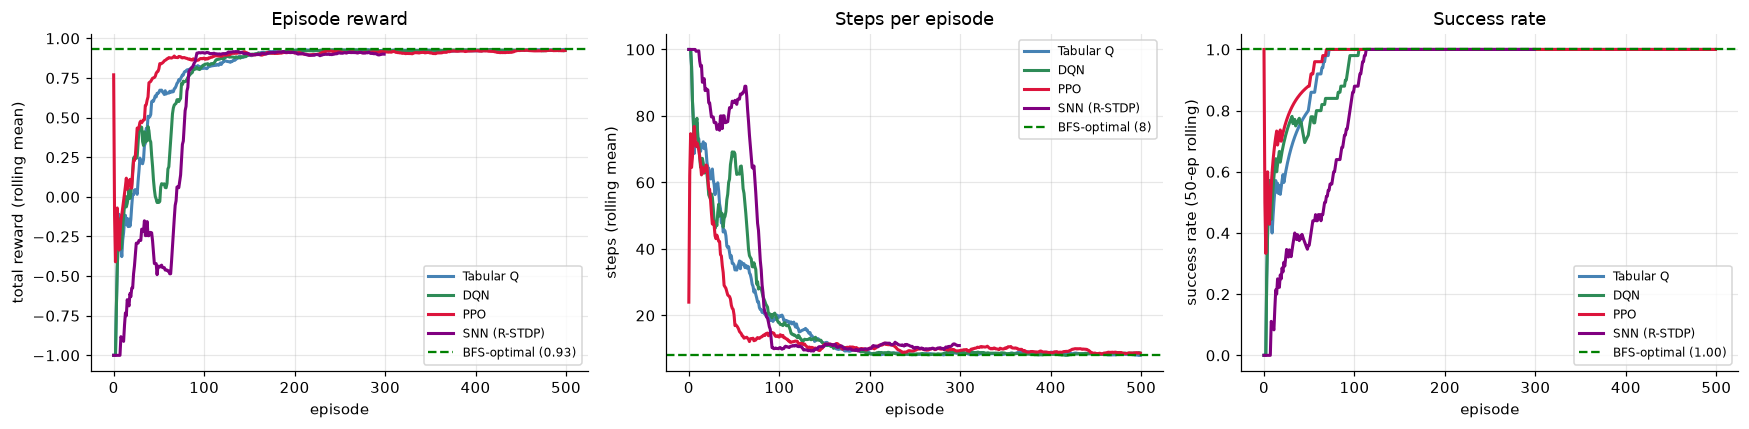

In [11]:
def smooth(x, window=20):
    return pd.Series(x).rolling(window=window, min_periods=1).mean().to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- reward ---
ax = axes[0]
ax.plot(smooth([m["total_reward"] for m in tabular_history]),
        label="Tabular Q", color="steelblue", linewidth=2)
ax.plot(smooth([m["total_reward"] for m in dqn_history]),
        label="DQN", color="seagreen", linewidth=2)
ax.plot(smooth([m["total_reward"] for m in ppo_history]),
        label="PPO", color="crimson", linewidth=2)
ax.plot(smooth([m["total_reward"] for m in snn_history]),
        label="SNN (R-STDP)", color="purple", linewidth=2)
ax.axhline(bfs_summary["mean_reward"], color="green", linestyle="--",
           label=f"BFS-optimal ({bfs_summary['mean_reward']:.2f})")
ax.set_xlabel("episode")
ax.set_ylabel("total reward (rolling mean)")
ax.set_title("Episode reward")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- steps ---
ax = axes[1]
ax.plot(smooth([m["steps"] for m in tabular_history]),
        label="Tabular Q", color="steelblue", linewidth=2)
ax.plot(smooth([m["steps"] for m in dqn_history]),
        label="DQN", color="seagreen", linewidth=2)
ax.plot(smooth([m["steps"] for m in ppo_history]),
        label="PPO", color="crimson", linewidth=2)
ax.plot(smooth([m["steps"] for m in snn_history]),
        label="SNN (R-STDP)", color="purple", linewidth=2)
ax.axhline(bfs_summary["mean_steps"], color="green", linestyle="--",
           label=f"BFS-optimal ({bfs_summary['mean_steps']:.0f})")
ax.set_xlabel("episode")
ax.set_ylabel("steps (rolling mean)")
ax.set_title("Steps per episode")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- success ---
ax = axes[2]
ax.plot(smooth([float(m["success"]) for m in tabular_history], 50),
        label="Tabular Q", color="steelblue", linewidth=2)
ax.plot(smooth([float(m["success"]) for m in dqn_history], 50),
        label="DQN", color="seagreen", linewidth=2)
ax.plot(smooth([float(m["success"]) for m in ppo_history], 50),
        label="PPO", color="crimson", linewidth=2)
ax.plot(smooth([float(m["success"]) for m in snn_history], 50),
        label="SNN (R-STDP)", color="purple", linewidth=2)
ax.axhline(1.0, color="green", linestyle="--", label="BFS-optimal (1.00)")
ax.set_xlabel("episode")
ax.set_ylabel("success rate (50-ep rolling)")
ax.set_title("Success rate")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "baseline_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Interpretation

**All adaptive methods reach the optimal policy.** Tabular Q, DQN, PPO
(sampled), and the SNN (sampled) all achieve 100% success rate and mean
rewards between 0.90 and 0.93. The BFS-optimal ceiling is 0.93.

**Convergence speed.** PPO converges fastest (~150 episodes), followed by
Tabular Q and DQN (~200 episodes), then the SNN (~100 episodes to reach
its plateau, but with more episodes spent in the initial exploration
phase). At 500 episodes all methods are at their plateau.

**Step efficiency.** Tabular Q and DQN reach the 8-step optimum. PPO
(sampled) reaches 9.0 steps. The SNN (sampled) reaches 10.0 steps. The
SNN is 25% slower than the optimum but matches the success rate — it
takes the long way around some states but always finds the goal.

**Greedy readout collapses for stochastic policies.** Both PPO and the
SNN fail under argmax evaluation (reward −1.0, 0% success), even though
their training reward is near-optimal and their sampled evaluation is
perfect. This is not an SNN-specific limitation: it is a property of the
task (symmetric optimal policy on an empty grid) combined with
deterministic readout (argmax collapses ties to a fixed action).
Tabular Q and DQN avoid this probably because their Q-values diverge slightly on
the tied actions during training, giving argmax a meaningful preference.
PPO and the SNN keep the tied actions closer to equal, so argmax fails.

**SNN is competitive.** For a spiking network with ~9,300 parameters,
trained entirely by local three-factor rules on the actor (no backprop
through the actor), reaching 100% success with 0.905 reward is a solid
result. The SNN trades two extra steps per episode for the compact,
biologically plausible learning rule.

**Implications for the noise study.** The natural stochasticity of the
SNN policy may become an advantage under noise: stochastic policies are
generally more robust to environmental perturbations than deterministic
ones, because they explore alternatives rather than committing to a
single action that might be disrupted. This is the hypothesis for
notebook 04.